# Tutorial 11B: Panel Data SFA - Exercise Solutions

This notebook contains complete solutions for all exercises in Tutorial 02.

In [ ]:
# Setup
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from panelbox.datasets import load_dataset
from panelbox.frontier import StochasticFrontier, lr_test

np.random.seed(42)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

os.makedirs("../outputs/figures/02_panel", exist_ok=True)
os.makedirs("../outputs/tables/latex", exist_ok=True)
os.makedirs("../outputs/tables/html", exist_ok=True)

print("Setup complete.")

---

## Exercise 1: Airline Efficiency Analysis (Easy)

Load `airline_panel.csv` and:
1. Estimate Pitt-Lee and BC92 models
2. Test if efficiency changed over time
3. Identify airlines with learning vs degradation
4. Visualize efficiency evolution

In [ ]:
# Step 1: Load airline data
airline_data = load_dataset("airline_panel", category="frontier")

print(f"Dataset shape: {airline_data.shape}")
print(f"Variables: {airline_data.columns.tolist()}")
print("\nPanel Structure:")
print(f"  Airlines: {airline_data['airline_id'].nunique()}")
print(f"  Years: {airline_data['year'].min()} - {airline_data['year'].max()}")
print(f"  Periods: {airline_data['year'].nunique()}")

airline_data.describe().round(4)

In [3]:
# Step 2: Estimate Pitt-Lee model
airline_pl_model = StochasticFrontier(
    data=airline_data,
    depvar="log_pass_km",
    exog=["log_aircraft", "log_employees", "log_fuel"],
    entity="airline_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="pitt_lee",
)

airline_pl_result = airline_pl_model.fit()

print("=" * 60)
print("AIRLINE PITT-LEE MODEL")
print("=" * 60)
print(airline_pl_result.summary())

AIRLINE PITT-LEE MODEL
                     Stochastic Frontier Analysis Results                     
Model:                  pitt_lee
Frontier:               production
Distribution:           half_normal
No. Observations:       750
No. Entities:           50
No. Time Periods:       15
Balanced Panel:         True
Log-Likelihood:         423.5632
AIC:                    -835.1265
BIC:                    -807.4061
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.112974
  σ_u (inefficiency):   0.131534
  σ (composite):        0.173391
  λ = σ_u/σ_v:          1.164284
  γ = σ²_u/σ²:          0.575472
------------------------------------------------------------------------------
Variance Decomposition:
  γ (inefficiency share):  0.5755
    95% CI:                [0.5755, 0.5755]
  λ (ratio σ_u/σ_v):       1.1643
    95% CI:                [1.1643, 1.1643]
  Interpretation: γ = 0.5755 

In [4]:
# Step 3: Estimate BC92 model
airline_bc92_model = StochasticFrontier(
    data=airline_data,
    depvar="log_pass_km",
    exog=["log_aircraft", "log_employees", "log_fuel"],
    entity="airline_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="bc92",
)

airline_bc92_result = airline_bc92_model.fit()

print("=" * 60)
print("AIRLINE BC92 MODEL")
print("=" * 60)
print(airline_bc92_result.summary())

# Extract eta
if hasattr(airline_bc92_result, "temporal_params") and "eta" in airline_bc92_result.temporal_params:
    eta = airline_bc92_result.temporal_params["eta"]
    print(f"\neta = {eta:.6f}")
    if eta > 0:
        print("Interpretation: Airlines are LEARNING (efficiency improves over time)")
    elif eta < 0:
        print("Interpretation: Airlines are DEGRADING (efficiency worsens over time)")
    else:
        print("Interpretation: No time trend in efficiency")

AIRLINE BC92 MODEL
              Panel Stochastic Frontier Analysis Results (BC92)               
Model:                  bc92
Frontier:               production
Distribution:           half_normal
No. Observations:       750
No. Entities:           50
No. Time Periods:       15
Balanced Panel:         True
Log-Likelihood:         439.6183
AIC:                    -865.2366
BIC:                    -832.8960
Converged:              True
------------------------------------------------------------------------------
Variance Components:
  σ_v (noise):          0.121743
  σ_u (inefficiency):   0.046251
  σ (composite):        0.130233
  λ = σ_u/σ_v:          0.379910
  γ = σ²_u/σ²:          0.126127
Temporal Parameters:
  η (decay parameter):  0.088340
    → Efficiency improves over time
------------------------------------------------------------------------------
------------------------------------------------------------------------------
Variance Decomposition:
  γ (inefficiency share)

In [5]:
# Step 4: LR test - Pitt-Lee vs BC92
lr_airline = lr_test(
    loglik_restricted=airline_pl_result.loglik,
    loglik_unrestricted=airline_bc92_result.loglik,
    df_diff=1,
)

print("=" * 60)
print("LR TEST: Pitt-Lee vs BC92 (Airlines)")
print("=" * 60)
print(f"LR Statistic: {lr_airline['statistic']:.4f}")
print(f"P-value:      {lr_airline['pvalue']:.4f}")
print(f"Conclusion:   {lr_airline['conclusion']}")

LR TEST: Pitt-Lee vs BC92 (Airlines)
LR Statistic: 32.1101
P-value:      0.0000
Conclusion:   Reject H0


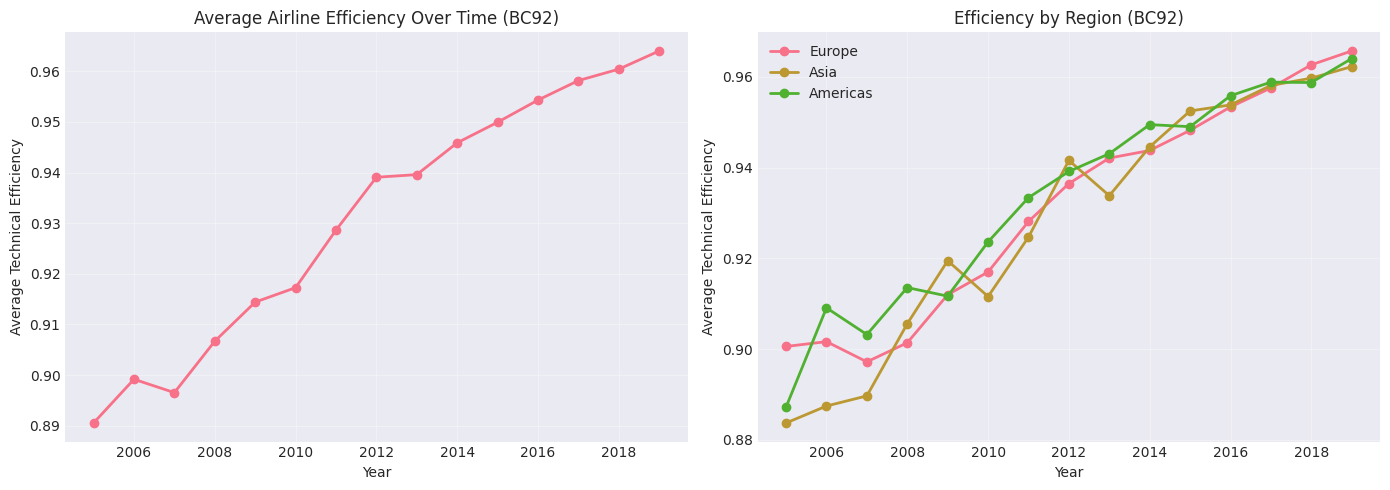


Efficiency by Region:
          count    mean     std     min     25%     50%     75%     max
region                                                                 
Americas  240.0  0.9333  0.0353  0.7809  0.9215  0.9432  0.9572  0.9740
Asia      255.0  0.9286  0.0389  0.7579  0.9149  0.9397  0.9559  0.9739
Europe    255.0  0.9312  0.0331  0.7935  0.9143  0.9405  0.9551  0.9722


In [6]:
# Step 5: Visualize efficiency evolution
airline_eff_bc92 = airline_bc92_result.efficiency(estimator="bc", by_period=True)
airline_data_eff = airline_data.copy()
airline_data_eff["te_bc92"] = airline_eff_bc92["efficiency"].values

# Average efficiency by year
avg_eff_airline = airline_data_eff.groupby("year")["te_bc92"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average efficiency over time
axes[0].plot(avg_eff_airline.index, avg_eff_airline.values, marker="o", linewidth=2)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Technical Efficiency")
axes[0].set_title("Average Airline Efficiency Over Time (BC92)")
axes[0].grid(True, alpha=0.3)

# Efficiency by region
for region in airline_data_eff["region"].unique():
    subset = airline_data_eff[airline_data_eff["region"] == region]
    avg = subset.groupby("year")["te_bc92"].mean()
    axes[1].plot(avg.index, avg.values, marker="o", linewidth=2, label=region)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average Technical Efficiency")
axes[1].set_title("Efficiency by Region (BC92)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary by region
print("\nEfficiency by Region:")
print(airline_data_eff.groupby("region")["te_bc92"].describe().round(4))

---

## Exercise 2: Policy Simulation (Medium)

Using the bank data and the BC95 model:
1. Estimate a BC95 model with `public_ownership` and `npl_ratio` as determinants
2. Simulate privatization of all public banks
3. Estimate the efficiency gain

In [ ]:
# Load bank data
bank_data = load_dataset("bank_panel", category="frontier")

# Step 1: Estimate BC95 model
bc95_model = StochasticFrontier(
    data=bank_data,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    inefficiency_vars=["public_ownership", "npl_ratio"],
    entity="bank_id",
    time="year",
    frontier="production",
    dist="truncated_normal",
    model_type="bc95",
)

bc95_result = bc95_model.fit()
print(bc95_result.summary())

In [8]:
# Step 2: Calculate efficiency under current scenario
# BC95 returns SFResult, so no by_period parameter
eff_current = bc95_result.efficiency(estimator="bc")
bank_data_eff = bank_data.copy()
bank_data_eff["te_current"] = eff_current["efficiency"].values

# Current efficiency: public vs private
public_banks = bank_data_eff[bank_data_eff["public_ownership"] == 1]
private_banks = bank_data_eff[bank_data_eff["public_ownership"] == 0]

print("Current Efficiency:")
print(f"  Public banks:  Mean TE = {public_banks['te_current'].mean():.4f}")
print(f"  Private banks: Mean TE = {private_banks['te_current'].mean():.4f}")
print(f"  Gap: {private_banks['te_current'].mean() - public_banks['te_current'].mean():.4f}")

Current Efficiency:
  Public banks:  Mean TE = 0.7763
  Private banks: Mean TE = 0.8868
  Gap: 0.1105


In [9]:
# Step 3: Counterfactual - privatize all banks
bank_data_cf = bank_data.copy()
bank_data_cf["public_ownership"] = 0  # Set all to private

# Re-estimate with counterfactual data
bc95_cf_model = StochasticFrontier(
    data=bank_data_cf,
    depvar="log_loans",
    exog=["log_labor", "log_capital", "log_deposits"],
    inefficiency_vars=["public_ownership", "npl_ratio"],
    entity="bank_id",
    time="year",
    frontier="production",
    dist="truncated_normal",
    model_type="bc95",
)

bc95_cf_result = bc95_cf_model.fit()
eff_cf = bc95_cf_result.efficiency(estimator="bc")
bank_data_eff["te_counterfactual"] = eff_cf["efficiency"].values

# Efficiency gain from privatization
public_mask = bank_data["public_ownership"] == 1
gain_public = (
    bank_data_eff.loc[public_mask, "te_counterfactual"].mean()
    - bank_data_eff.loc[public_mask, "te_current"].mean()
)
gain_overall = bank_data_eff["te_counterfactual"].mean() - bank_data_eff["te_current"].mean()

print("=" * 60)
print("POLICY SIMULATION: Privatization of Public Banks")
print("=" * 60)
print("\nCurrent scenario:")
print(f"  Overall mean TE:      {bank_data_eff['te_current'].mean():.4f}")
print(f"  Public banks mean TE: {bank_data_eff.loc[public_mask, 'te_current'].mean():.4f}")
print("\nCounterfactual (all privatized):")
print(f"  Overall mean TE:      {bank_data_eff['te_counterfactual'].mean():.4f}")
print(f"  Former public banks:  {bank_data_eff.loc[public_mask, 'te_counterfactual'].mean():.4f}")
print("\nEstimated efficiency gain:")
print(f"  For public banks: +{gain_public:.4f} ({gain_public * 100:.2f} pp)")
print(f"  Overall system:   +{gain_overall:.4f} ({gain_overall * 100:.2f} pp)")

POLICY SIMULATION: Privatization of Public Banks

Current scenario:
  Overall mean TE:      0.8548
  Public banks mean TE: 0.7763

Counterfactual (all privatized):
  Overall mean TE:      0.8383
  Former public banks:  0.7514

Estimated efficiency gain:
  For public banks: +-0.0250 (-2.50 pp)
  Overall system:   +-0.0165 (-1.65 pp)


---

## Exercise 3: Comprehensive Model Selection (Hard)

Estimate all panel models for airline data and create a comprehensive comparison.

In [ ]:
# Step 1: Estimate all models for airline data
airline_data = load_dataset("airline_panel", category="frontier")

exog_vars = ["log_aircraft", "log_employees", "log_fuel"]
models_results = {}

# Pitt-Lee
pl_model = StochasticFrontier(
    data=airline_data,
    depvar="log_pass_km",
    exog=exog_vars,
    entity="airline_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="pitt_lee",
)
models_results["Pitt-Lee"] = pl_model.fit()
print("Pitt-Lee: done")

# BC92
bc92_model = StochasticFrontier(
    data=airline_data,
    depvar="log_pass_km",
    exog=exog_vars,
    entity="airline_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="bc92",
)
models_results["BC92"] = bc92_model.fit()
print("BC92: done")

# Kumbhakar
kumb_model = StochasticFrontier(
    data=airline_data,
    depvar="log_pass_km",
    exog=exog_vars,
    entity="airline_id",
    time="year",
    frontier="production",
    dist="half_normal",
    model_type="kumbhakar_1990",
)
models_results["Kumbhakar"] = kumb_model.fit()
print("Kumbhakar: done")

# CSS
css_model = StochasticFrontier(
    data=airline_data,
    depvar="log_pass_km",
    exog=exog_vars,
    entity="airline_id",
    time="year",
    frontier="production",
    model_type="css",
    css_time_trend="quadratic",
)
models_results["CSS"] = css_model.fit()
print("CSS: done")

print("\nAll models estimated successfully.")

In [11]:
# Step 2: Create comparison table
comparison_rows = []
efficiency_means = {}

for name, result in models_results.items():
    try:
        if name == "CSS":
            # CSS may not have standard efficiency
            if hasattr(result, "_css_result"):
                eff_entity = result._css_result.efficiency_by_entity()
                mean_te = eff_entity["mean_efficiency"].mean()
            else:
                eff = result.efficiency(estimator="bc")
                mean_te = eff["efficiency"].mean()
        elif name == "Pitt-Lee":
            eff = result.efficiency(estimator="bc")
            mean_te = eff["efficiency"].mean()
        else:
            eff = result.efficiency(estimator="bc", by_period=True)
            mean_te = eff["efficiency"].mean()
        efficiency_means[name] = mean_te
    except Exception:
        mean_te = np.nan
        efficiency_means[name] = mean_te

    comparison_rows.append(
        {
            "Model": name,
            "Log-Likelihood": result.loglik if result.loglik else np.nan,
            "AIC": result.aic if result.aic else np.nan,
            "BIC": result.bic if result.bic else np.nan,
            "N Parameters": result.nparams,
            "Mean TE": mean_te,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)

# Add rankings for models with valid AIC/BIC
valid_aic = comparison_df["AIC"].notna()
comparison_df.loc[valid_aic, "AIC_Rank"] = comparison_df.loc[valid_aic, "AIC"].rank().astype(int)
comparison_df.loc[valid_aic, "BIC_Rank"] = comparison_df.loc[valid_aic, "BIC"].rank().astype(int)

print("=" * 80)
print("COMPREHENSIVE MODEL COMPARISON (AIRLINE DATA)")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Best models
valid = comparison_df[comparison_df["AIC"].notna()]
if len(valid) > 0:
    print(f"\nBest by AIC: {valid.loc[valid['AIC'].idxmin(), 'Model']}")
    print(f"Best by BIC: {valid.loc[valid['BIC'].idxmin(), 'Model']}")

COMPREHENSIVE MODEL COMPARISON (AIRLINE DATA)
    Model  Log-Likelihood         AIC         BIC  N Parameters  Mean TE  AIC_Rank  BIC_Rank
 Pitt-Lee      423.563246 -835.126492 -807.406053             6 0.903081       2.0       2.0
     BC92      439.618279 -865.236558 -832.896046             7 0.930974       1.0       1.0
Kumbhakar      416.619523 -815.239046 -773.658387             9 0.964329       3.0       3.0
      CSS             NaN         NaN         NaN             3 0.751507       NaN       NaN

Best by AIC: BC92
Best by BIC: BC92


In [12]:
# Step 3: LR tests between nested models
print("=" * 60)
print("NESTED MODEL TESTS")
print("=" * 60)

# Pitt-Lee vs BC92
if models_results["Pitt-Lee"].loglik and models_results["BC92"].loglik:
    lr1 = lr_test(
        loglik_restricted=models_results["Pitt-Lee"].loglik,
        loglik_unrestricted=models_results["BC92"].loglik,
        df_diff=1,
    )
    print("\nPitt-Lee vs BC92:")
    print(f"  LR stat = {lr1['statistic']:.4f}, p = {lr1['pvalue']:.4f}")
    print(f"  {lr1['conclusion']}")

# Pitt-Lee vs Kumbhakar
if models_results["Pitt-Lee"].loglik and models_results["Kumbhakar"].loglik:
    lr2 = lr_test(
        loglik_restricted=models_results["Pitt-Lee"].loglik,
        loglik_unrestricted=models_results["Kumbhakar"].loglik,
        df_diff=2,  # b and c parameters
    )
    print("\nPitt-Lee vs Kumbhakar:")
    print(f"  LR stat = {lr2['statistic']:.4f}, p = {lr2['pvalue']:.4f}")
    print(f"  {lr2['conclusion']}")

NESTED MODEL TESTS

Pitt-Lee vs BC92:
  LR stat = 32.1101, p = 0.0000
  Reject H0

Pitt-Lee vs Kumbhakar:
  LR stat = 0.0000, p = 1.0000
  Do not reject H0


In [13]:
# Step 4: Summary and justification
print("=" * 60)
print("MODEL SELECTION SUMMARY")
print("=" * 60)

print("\n1. STATISTICAL CRITERIA:")
valid = comparison_df[comparison_df["AIC"].notna()]
if len(valid) > 0:
    best_aic = valid.loc[valid["AIC"].idxmin(), "Model"]
    best_bic = valid.loc[valid["BIC"].idxmin(), "Model"]
    print(f"   Best AIC: {best_aic}")
    print(f"   Best BIC: {best_bic}")

print("\n2. ECONOMIC INTERPRETATION:")
if (
    hasattr(models_results["BC92"], "temporal_params")
    and "eta" in models_results["BC92"].temporal_params
):
    eta_val = models_results["BC92"].temporal_params["eta"]
    print(
        f"   BC92 eta = {eta_val:.4f}: {'learning' if eta_val > 0 else 'degradation' if eta_val < 0 else 'no trend'}"
    )

print("\n3. ROBUSTNESS:")
print(f"   CSS mean TE: {efficiency_means.get('CSS', np.nan):.4f}")
for name in ["Pitt-Lee", "BC92", "Kumbhakar"]:
    if name in efficiency_means:
        print(f"   {name} mean TE: {efficiency_means[name]:.4f}")

print("\n4. RECOMMENDATION:")
print("   Consider the model that balances statistical fit (AIC/BIC),")
print("   economic interpretability, and robustness to specification.")
print("   For policy analysis, BC95 with determinants provides actionable insights.")
print("   For forecasting, the best AIC/BIC model is preferred.")

MODEL SELECTION SUMMARY

1. STATISTICAL CRITERIA:
   Best AIC: BC92
   Best BIC: BC92

2. ECONOMIC INTERPRETATION:
   BC92 eta = 0.0883: learning

3. ROBUSTNESS:
   CSS mean TE: 0.7515
   Pitt-Lee mean TE: 0.9031
   BC92 mean TE: 0.9310
   Kumbhakar mean TE: 0.9643

4. RECOMMENDATION:
   Consider the model that balances statistical fit (AIC/BIC),
   economic interpretability, and robustness to specification.
   For policy analysis, BC95 with determinants provides actionable insights.
   For forecasting, the best AIC/BIC model is preferred.
